# This tutorial provides a simple implementation of LSTM using Keras.
# A time series dataset is used in this example

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.layers import Input, LSTM, Activation, Dropout, Dense
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras import layers
import tensorflow as tf

In [2]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

The dataset is downloaded from Kaggle "https://www.kaggle.com/datasets/harunshimanto/epileptic-seizure-recognition/data". <br>The original dataset from the UCI Machine Learning Repository consists of 5 different folders, each with 100 files, with each file representing a single subject/person.<br> Each file is a recording of brain activity for 23.6 seconds. The corresponding time-series is sampled into 4097 data points.<br>Each data point is the value of the EEG recording at a different point in time. So we have total 500 individuals with each has 4097 data points for 23.5 seconds.

4097 data points was divided into 23 chunks, each chunk contains 178 data points for 1 second.<br> Each data point is the value of the EEG recording at a different point in time.<br> So now we have 23 x 500 = 11500 pieces of information(row), each information contains 178 data points for 1 second(column), the last column represents the label y {1,2,3,4,5}.

The response variable is y in column 179, the Explanatory variables X1, X2, …, X178

In [3]:
data = pd.read_csv('data/Epileptic_Seizure.csv')
print(data.shape)
data = data.drop(['Unnamed'], axis = 1)  #drop the first column as it is irrelevant
print(data.head())

(11500, 180)
    X1   X2   X3   X4   X5   X6   X7   X8   X9  X10  ...  X170  X171  X172  \
0  135  190  229  223  192  125   55   -9  -33  -38  ...   -17   -15   -31   
1  386  382  356  331  320  315  307  272  244  232  ...   164   150   146   
2  -32  -39  -47  -37  -32  -36  -57  -73  -85  -94  ...    57    64    48   
3 -105 -101  -96  -92  -89  -95 -102 -100  -87  -79  ...   -82   -81   -80   
4   -9  -65  -98 -102  -78  -48  -16    0  -21  -59  ...     4     2   -12   

   X173  X174  X175  X176  X177  X178  y  
0   -77  -103  -127  -116   -83   -51  4  
1   152   157   156   154   143   129  1  
2    19   -12   -30   -35   -35   -36  5  
3   -77   -85   -77   -72   -69   -65  5  
4   -32   -41   -65   -83   -89   -73  5  

[5 rows x 179 columns]


y contains the category of the 178-dimensional input vector. Specifically y in {1, 2, 3, 4, 5}:

5 - eyes open, means when they were recording the EEG signal of the brain the patient had their eyes open

4 - eyes closed, means when they were recording the EEG signal the patient had their eyes closed

3 - Yes they identify where the region of the tumor was in the brain and recording the EEG activity from the healthy brain area

2 - They recorder the EEG from the area where the tumor was located

1 - Recording of seizure activity

So 1 is the postive class with the remaining converted to 0

In [4]:
X = data.iloc[:,:-1].values
y = data.loc[:,['y']].values
y[y>1] = 0
print(X.shape, y.shape)

(11500, 178) (11500, 1)


Divide the dataset into 60:20:20 for training, validation and testing. <br>The stratify is used so that equal ration of each class gets shuffled during the split into training, testing and validation.

**Note: This is not a good way to split time series data as neighboring data points, which are highly correlated, are split into different sets and test accuracy appears artificially high. <br>However, this is a simple example to show how to use LSTM with time series in Keras.**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, shuffle = True)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size = 0.25, stratify=y_train, shuffle = True)
print('Training data:', X_train.shape, y_train.shape)
print('Validation data:', X_valid.shape, y_valid.shape)
print('Training data:', X_test.shape, y_test.shape)

Training data: (6900, 178) (6900, 1)
Validation data: (2300, 178) (2300, 1)
Training data: (2300, 178) (2300, 1)


A simple LSTM network is used. The Keras sequential model is used and dropout layers are added. Final layer is used with sigmoid activation function.

In [6]:
model = Sequential()
model.add(LSTM(units=256,
               input_shape=(X_train.shape[1], 1), 
               return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(units=128, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(units=64))
model.add(Dropout(0.3))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

In [7]:
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',  
              metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 178, 256)          264192    
                                                                 
 dropout (Dropout)           (None, 178, 256)          0         
                                                                 
 lstm_1 (LSTM)               (None, 178, 128)          197120    
                                                                 
 dropout_1 (Dropout)         (None, 178, 128)          0         
                                                                 
 lstm_2 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 16)                1

Total params: 511777 (1.95 MB)
Trainable params: 511777 (1.95 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [8]:
NUM_EPOCHS = 5
BATCH_SIZE = 30
history = model.fit(X_train, y_train, epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_valid, y_valid))

Epoch 1/5
230/230 [==============================] - 145s 610ms/step - loss: 0.1956 - accuracy: 0.9346 - val_loss: 0.1271 - val_accuracy: 0.9617
Epoch 2/5
230/230 [==============================] - 155s 674ms/step - loss: 0.1182 - accuracy: 0.9636 - val_loss: 0.1206 - val_accuracy: 0.9648
Epoch 3/5
230/230 [==============================] - 159s 694ms/step - loss: 0.1077 - accuracy: 0.9667 - val_loss: 0.0937 - val_accuracy: 0.9617
Epoch 4/5
230/230 [==============================] - 156s 677ms/step - loss: 0.0943 - accuracy: 0.9690 - val_loss: 0.1123 - val_accuracy: 0.9735
Epoch 5/5
230/230 [==============================] - 155s 673ms/step - loss: 0.0876 - accuracy: 0.9743 - val_loss: 0.0878 - val_accuracy: 0.9665


Final Validation Accuracy: 0.967


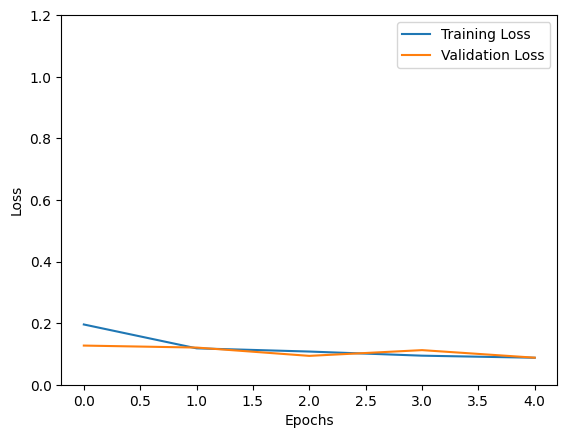

In [9]:
print("Final Validation Accuracy: %0.3f" % history.history['val_accuracy'][-1])
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.ylim([0,1.2])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [10]:
predictions = model.predict(X_test)
print(predictions.shape)
y_pred = np.round(predictions[:, 0])
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

72/72 [==============================] - 16s 200ms/step
(2300, 1)
0.9665217391304348
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1840
           1       0.98      0.85      0.91       460

    accuracy                           0.97      2300
   macro avg       0.97      0.92      0.94      2300
weighted avg       0.97      0.97      0.97      2300



Plot the confusion matrix

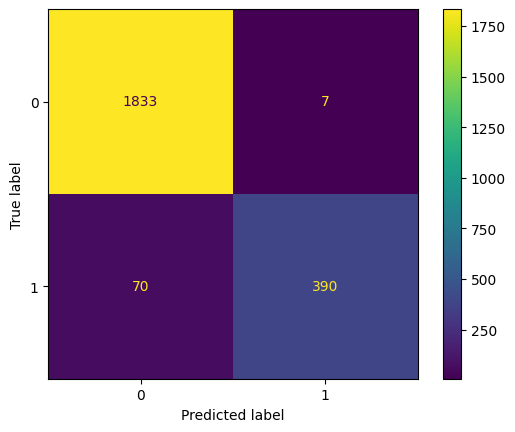

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()